In [ ]:
!pip install boruta pycaret scikit-learn imbalanced-learn -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from boruta import BorutaPy
from sklearn.preprocessing import MinMaxScaler

In [22]:
data=pd.read_csv(r"../../data/processed/data_final.csv")
data.head()

,Date,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,...,GJR_VaR_95,Signal1_Buy,Signal1_Sell,Signal2_Buy,Signal2_Sell,Signal3_Buy,Signal3_Sell,Signal4_Buy,Signal4_Sell,Risk_Label
0,2009-04-17,2503.935059,17370.0,875.0,51.959999,867.400024,13.371,1325.800049,1673.069946,483.799988,...,-2.246073,0,0,0,0,0,0,0,0,lowrisk
1,2009-04-20,2557.456055,17480.0,876.0,51.959999,887.000000,13.536,1327.500000,1608.209961,491.940002,...,-2.169582,0,0,0,0,0,0,0,0,lowrisk
2,2009-04-21,2535.827881,17480.0,855.0,51.959999,882.099976,13.727,1354.300049,1643.849976,497.190002,...,-2.062932,0,0,0,0,0,0,0,0,lowrisk
3,2009-04-22,2461.345947,17715.0,856.0,51.959999,891.799988,13.726,1346.599976,1646.119995,509.899994,...,-2.000966,0,0,0,0,0,0,0,0,lowrisk
4,2009-04-23,2463.954102,17895.0,862.0,51.959999,905.900024,13.618,1333.599976,1652.209961,514.090027,...,-1.900311,0,0,0,0,0,1,0,0,lowrisk


### Min-Max Scaling

In [27]:
X = data.drop(['Risk_Label', 'Date'], axis=1) #설명변수
y = data['Risk_Label'] #반응변수

# 스케일링
scaler = MinMaxScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)
X_scaled = pd.concat([X_scaled, data['Date']], axis=1)
X_scaled.set_index('Date', inplace=True)
X_scaled

,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,...,VaR_95,GJR_VaR_95,Signal1_Buy,Signal1_Sell,Signal2_Buy,Signal2_Sell,Signal3_Buy,Signal3_Sell,Signal4_Buy,Signal4_Sell
Date,,,,,,,,,,,,,,,,,,,,,
2009-04-17,0.171840,0.004423,0.047953,0.300322,0.000000,0.693599,0.670306,0.002902,0.094800,0.005265,...,0.785634,0.796254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-04-20,0.188488,0.005833,0.048246,0.300322,0.004403,0.717357,0.673802,0.000000,0.105193,0.006514,...,0.799784,0.808015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-04-21,0.181760,0.005833,0.042105,0.300322,0.003303,0.744858,0.728912,0.001595,0.111896,0.006076,...,0.811914,0.824414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-04-22,0.158592,0.008846,0.042398,0.300322,0.005482,0.744714,0.713078,0.001696,0.128123,0.009218,...,0.824842,0.833942,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-04-23,0.159403,0.011154,0.044152,0.300322,0.008650,0.729163,0.686346,0.001969,0.133473,0.011458,...,0.823671,0.849419,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-23,0.662729,0.896346,0.961988,0.480074,0.974455,0.115622,0.912215,0.940439,0.947921,0.898903,...,0.493898,0.592471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2026-02-24,0.673721,0.923846,0.964912,0.473447,0.963469,0.111008,0.909665,0.951017,0.964531,0.926440,...,0.520930,0.625358,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-25,0.682997,0.946987,0.974854,0.474183,0.974837,0.098429,0.905120,0.963920,0.964851,0.948261,...,0.525373,0.642833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### train:valid:test = 5:3:2

In [34]:
#데이터 셋을 5:3:2로 나누기

X_scaled_train=X_scaled[:int(0.5*len(X_scaled))]
y_train=y[:int(0.5*len(y))]

In [ ]:
# 랜덤 포레스트 + Boruta (class_weight 2개 자동 실행)
import io
from contextlib import redirect_stdout

class_weight_options = [None, 'balanced']
boruta_results = {}
selected_features_by_weight = {}
summary_rows = []

for cw in class_weight_options:
    # 랜덤 포레스트
    rf = RandomForestClassifier(
        n_jobs=-1,                  #병렬 처리
        class_weight=cw,            #클래스 불균형 처리(vs 'balanced')
        max_depth=None,             #트리 깊이 제한
        n_estimators=500,           #트리 수
        random_state=1              #seed 고정
    )

    # BorutaPy 객체 생성
    selector = BorutaPy(
        estimator=rf,
        perc=100,              # shadow 기준 (엄격)
        alpha=0.05,            # 유의수준
        max_iter=50,           # Boruta 반복 횟수
        random_state=1         # seed 고정
        )

    # Boruta 실행
    boruta_result=selector.fit(X_scaled_train.values, y_train.values)
    
    if cw is None:
        #클래스 불균형 유지
        result1=boruta_result
        selected_features1 = X.columns[boruta_result.support_]
    else:
        #클래스 불균형 처리
        result2=boruta_result
        selected_features2 = X.columns[boruta_result.support_]
        
    
print("\n", selected_features1, "\n")
print("\n", selected_features2, "\n")
    


 Index(['KODEX 200', 'TOPIX', 'Gold Spot', 'JPY/KRW', 'NASDAQ', 'KOSDAQ',
       'KOSPI 200 Close', 'KOSPI 200 Open', 'KOSPI 200_MA5', 'KOSPI 200_RSI14',
       'KOSPI 200_BB_UPPER15', 'Actual_Return(%)', 'Signal2_Sell'],
      dtype='object') 


 Index(['KODEX 200', 'TOPIX', 'Gold Spot', 'JPY/KRW', 'NASDAQ',
       'KOSPI 200 Close', 'KOSPI 200 Low', 'KOSPI 200_RSI14',
       'Actual_Return(%)', 'GJR_GARCH_Vol', 'GJR_VaR_95', 'Signal2_Sell'],
      dtype='object') 



In [58]:
# result1/result2 변수 중요도 퍼센트 테이블

def build_importance_pct_table(selector, label):
    imp_history = np.array(selector.importance_history_)
    n_features = len(X.columns)

    # 중요도를 퍼센트로 정규화
    imp_real = imp_history[:, :n_features].astype(float)
    imp_real[imp_real == 0] = np.nan
    row_sums = np.nansum(imp_real, axis=1, keepdims=True)
    row_sums[row_sums == 0] = np.nan
    imp_pct = 100 * imp_real / row_sums

    mean_pct = np.nanmean(imp_pct, axis=0)
    mean_pct = np.nan_to_num(mean_pct, nan=0.0)

    table = pd.DataFrame({
        'feature': X.columns,
        'Importance_pct': mean_pct,
        'status': 'Rejected'
    })
    table.loc[selector.support_, 'status'] = 'Confirmed'
    table.loc[selector.support_weak_, 'status'] = 'Tentative'

    return table.sort_values('Importance_pct', ascending=False).reset_index(drop=True)


table_result1 = build_importance_pct_table(result1,'None')
table_result2 = build_importance_pct_table(result2, 'balanced')

print('None 변수 중요도(%)')
display(table_result1)

print('balanced 변수 중요도(%)')
display(table_result2)

# 필요 시 합쳐서 비교
importance_pct_compare = pd.concat([table_result1, table_result2], ignore_index=True)

None 변수 중요도(%)


C:\Users\USER\AppData\Local\Temp\ipykernel_14632\106234493.py:14: RuntimeWarning: Mean of empty slice
  mean_pct = np.nanmean(imp_pct, axis=0)


,feature,Importance_pct,status
0,Actual_Return(%),76.856750,Confirmed
1,KOSPI 200_RSI14,3.577778,Confirmed
2,Signal2_Sell,3.326086,Confirmed
3,KOSPI 200 Close,1.317297,Confirmed
4,KODEX 200,1.277070,Confirmed
5,TOPIX,1.196657,Confirmed
6,NASDAQ,1.177408,Confirmed
7,KOSDAQ,1.165763,Confirmed
8,KOSPI 200_MA5,1.153347,Confirmed
9,KOSPI 200_BB_UPPER15,1.101906,Confirmed


balanced 변수 중요도(%)


,feature,Importance_pct,status
0,Actual_Return(%),73.482028,Confirmed
1,KOSPI 200_RSI14,6.706083,Confirmed
2,Signal2_Sell,2.343172,Confirmed
3,KODEX 200,1.633125,Confirmed
4,NASDAQ,1.608349,Confirmed
5,KOSPI 200 Close,1.564693,Confirmed
6,JPY/KRW,1.520254,Confirmed
7,TOPIX,1.406294,Confirmed
8,Gold Spot,1.207012,Confirmed
9,GJR_VaR_95,1.164733,Confirmed


C:\Users\USER\AppData\Local\Temp\ipykernel_14632\2584769290.py:23: RuntimeWarning: Mean of empty slice
  mean_imp = np.nanmean(plot_values, axis=0)


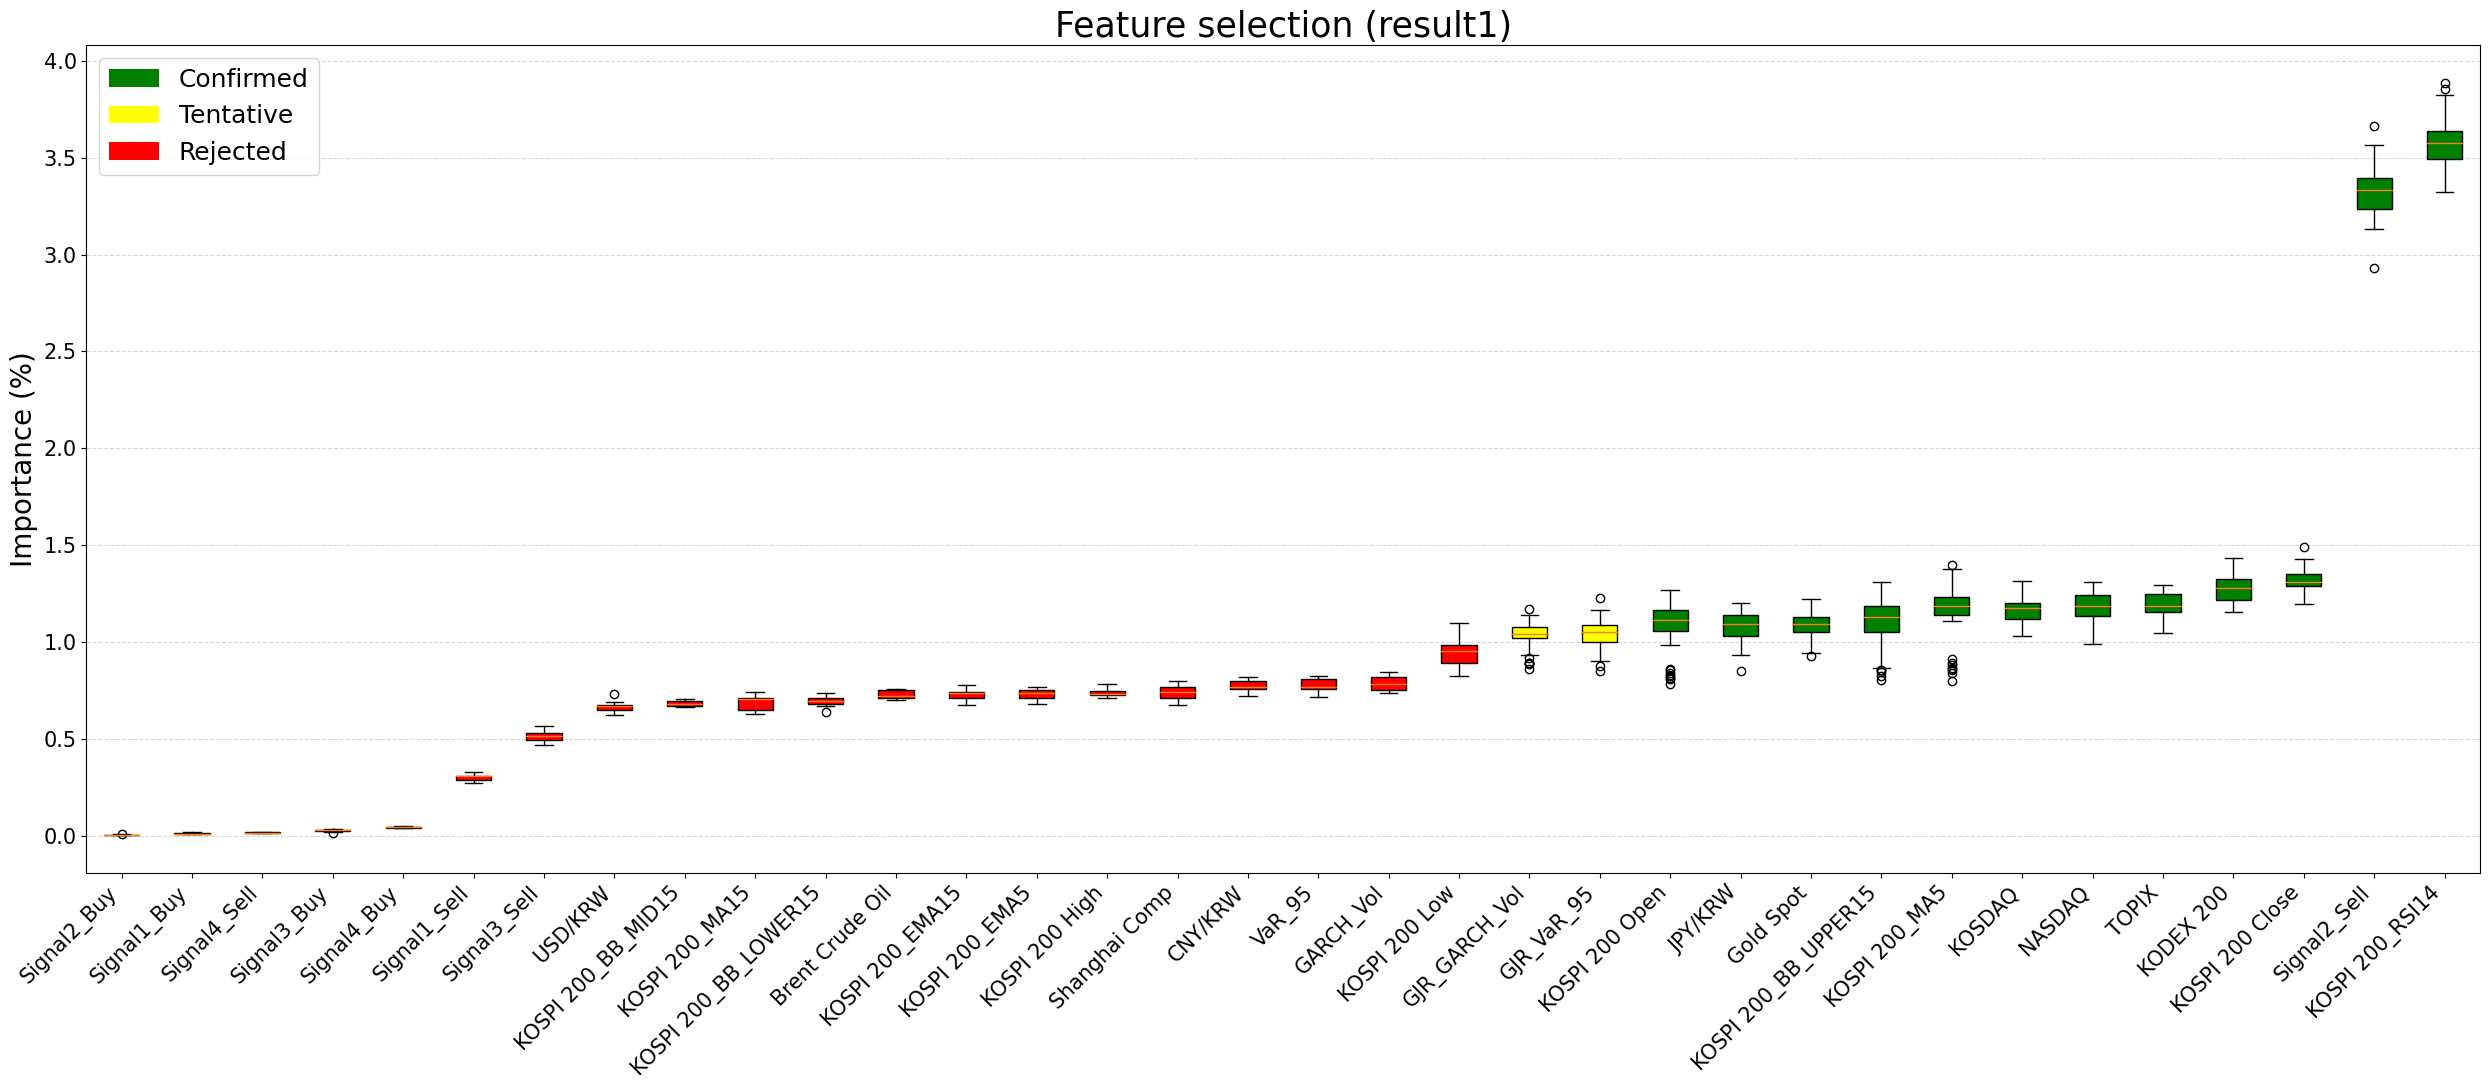

C:\Users\USER\AppData\Local\Temp\ipykernel_14632\2584769290.py:23: RuntimeWarning: Mean of empty slice
  mean_imp = np.nanmean(plot_values, axis=0)


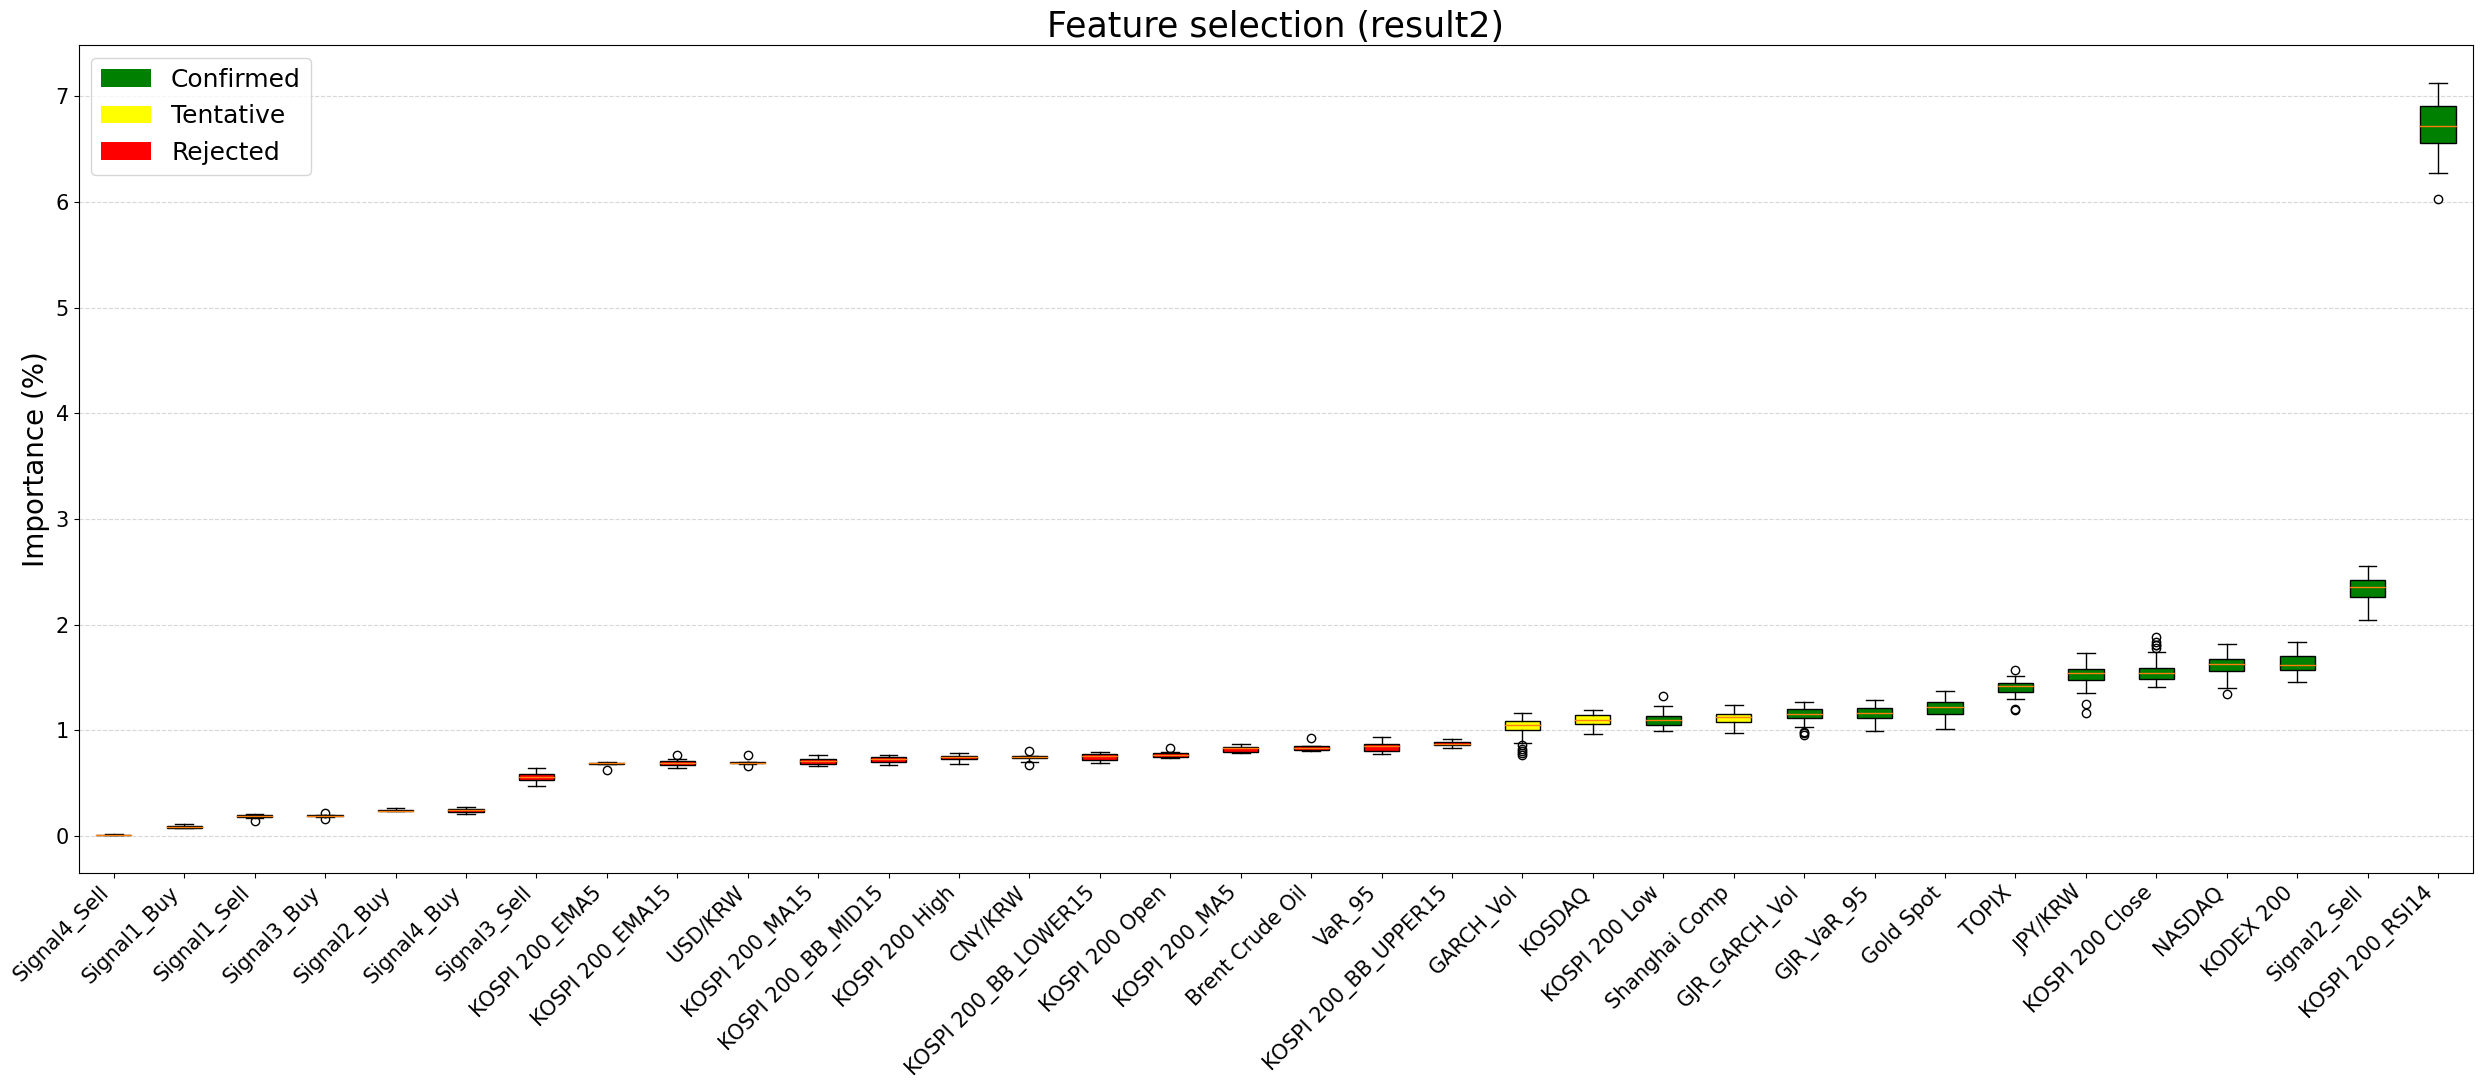

In [ ]:
# result1, result2 각각 동일 로직으로 시각화

def plot_boruta_result(selector, plot_title):
    # Boruta importance history 가져오기
    imp_history = np.array(selector.importance_history_)
    n_features = len(X.columns)

    # Z-score를 퍼센트로 변환 (전부 NaN이면 raw importance로 폴백)
    imp_real = imp_history[:, :n_features].astype(float)
    imp_real[imp_real == 0] = np.nan
    row_sums = np.nansum(imp_real, axis=1, keepdims=True)
    row_sums[row_sums == 0] = np.nan
    imp_pct_local = 100 * imp_real / row_sums

    use_fallback_raw = np.isnan(imp_pct_local).all()
    plot_values = imp_real if use_fallback_raw else imp_pct_local
    y_label = "Importance (Z-score)" if use_fallback_raw else "Importance (%)"

    # 평균 importance 계산
    mean_imp = np.nanmean(plot_values, axis=0)

    # DataFrame 생성 및 정렬
    feat_df_local = pd.DataFrame({
        'feature': X.columns,
        'mean_importance': mean_imp,
        'status': ['Rejected'] * n_features
    })

    feat_df_local.loc[selector.support_, 'status'] = 'Confirmed'
    feat_df_local.loc[selector.support_weak_, 'status'] = 'Tentative'
    feat_df_local = feat_df_local.sort_values(by='mean_importance', ascending=True)

    # Boxplot 데이터 준비
    sorted_features = feat_df_local['feature'].tolist()
    sorted_status = feat_df_local['status'].tolist()
    sorted_idx = [list(X.columns).index(f) for f in sorted_features]
    values_sorted = plot_values[:, sorted_idx]

    box_data = []
    valid_features = []
    valid_status = []
    for i, feat in enumerate(sorted_features):
        vals = values_sorted[:, i]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        box_data.append(vals)
        valid_features.append(feat)
        valid_status.append(sorted_status[i])

    if len(box_data) == 0:
        raise ValueError(f"{plot_title}: 표시할 유효 importance 값이 없습니다. Boruta max_iter를 늘려보세요.")

    # 색상 설정
    color_map = {'Confirmed': 'green', 'Tentative': 'yellow', 'Rejected': 'red'}
    box_colors = [color_map[s] for s in valid_status]

    # Plot (가장 큰 변수 제외) -> Boruta돌리고 크기차이 너무 날 경우
    box_data = box_data[:-1] if len(box_data) > 1 else box_data
    valid_features = valid_features[:-1] if len(valid_features) > 1 else valid_features
    box_colors = box_colors[:-1] if len(box_colors) > 1 else box_colors

    plt.figure(figsize=(25, 11))
    bp = plt.boxplot(box_data, patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)

    plt.xticks(range(1, len(valid_features)+1), valid_features,
               rotation=45, ha='right', fontsize=15)
    plt.ylabel(y_label, fontsize=20)
    plt.yticks(fontsize=15)
    plt.title(plot_title, fontsize=25)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    legend_elements = [Patch(facecolor='green', label='Confirmed'),
                       Patch(facecolor='yellow', label='Tentative'),
                       Patch(facecolor='red', label='Rejected')]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=18)
    plt.tight_layout()
    plt.show()

    return feat_df_local, plot_values


# 2개 결과 각각 plot
feat_df_result1, imp_pct_result1 = plot_boruta_result(result1, "Feature selection (result1)")
feat_df_result2, imp_pct_result2 = plot_boruta_result(result2, "Feature selection (result2)")


# 사실 별 필요없어보임 ㅋ

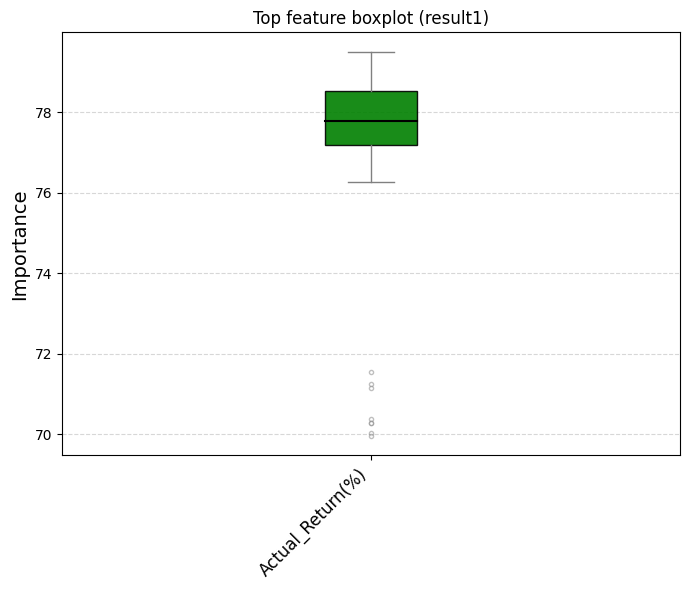

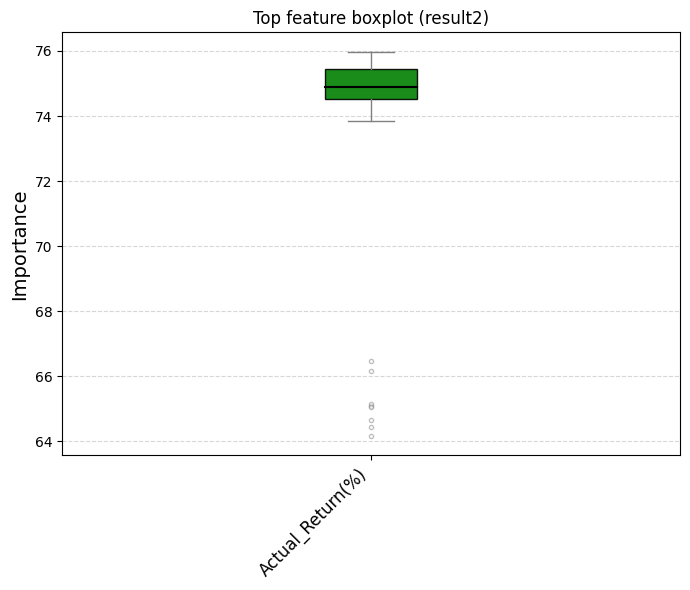

In [52]:
# result1/result2 각각 상위 변수 플롯
if 'feat_df_result1' not in globals() or 'feat_df_result2' not in globals():
    raise NameError("먼저 9번 셀을 실행해 feat_df_result1/2, imp_pct_result1/2를 생성하세요.")


def plot_top_features(feat_df_local, imp_pct_local, title, top_n=2):
    # 중요도 상위 변수 선택
    top_df = feat_df_local.sort_values(by='mean_importance', ascending=False).head(top_n)
    top_feature = top_df['feature'].tolist()
    top_status = top_df['status'].tolist()
    top_idx = [list(X.columns).index(f) for f in top_feature]

    vals = imp_pct_local[:, top_idx]

    # 각 변수별 유효값만 추출
    box_vals = []
    box_labels = []
    box_status = []
    for i, f in enumerate(top_feature):
        v = vals[:, i]
        v = v[np.isfinite(v)]
        if len(v) == 0:
            continue
        box_vals.append(v)
        box_labels.append(f)
        box_status.append(top_status[i])

    if len(box_vals) == 0:
        raise ValueError(f"{title}: 표시할 유효 값이 없습니다.")

    plt.figure(figsize=(7, 6))
    bp = plt.boxplot(box_vals, patch_artist=True, showfliers=True)

    color_map = {
        'Confirmed': 'green',
        'Tentative': 'yellow',
        'Rejected': 'red'
    }
    top_color = [color_map[s] for s in box_status]

    for patch, color in zip(bp['boxes'], top_color):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)

    for whisker in bp['whiskers']:
        whisker.set(color='gray', linewidth=1)

    for cap in bp['caps']:
        cap.set(color='gray', linewidth=1)

    for median in bp['medians']:
        median.set(color='black', linewidth=1.5)

    for flier in bp['fliers']:
        flier.set(marker='o', markersize=3, alpha=0.5,
                  markerfacecolor='white', markeredgecolor='gray')

    plt.xticks(range(1, len(box_labels) + 1), box_labels, rotation=45, ha='right', fontsize=12)
    plt.ylabel("Importance", fontsize=14)
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


plot_top_features(feat_df_result1, imp_pct_result1, "Top feature boxplot (result1)", top_n=1)
plot_top_features(feat_df_result2, imp_pct_result2, "Top feature boxplot (result2)", top_n=1)

In [72]:
data_None=data[selected_features1]
data_balanced=data[selected_features2]

data_None["Data"]=data["Date"]
data_balanced["Data"]=data["Date"]

data_None.set_index("Data", inplace=True)
data_balanced.set_index("Data", inplace=True)

data_None.tail()


C:\Users\USER\AppData\Local\Temp\ipykernel_14632\1844162605.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_None["Data"]=data["Date"]
C:\Users\USER\AppData\Local\Temp\ipykernel_14632\1844162605.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_balanced["Data"]=data["Date"]


,KODEX 200,TOPIX,Gold Spot,JPY/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,KOSPI 200 Open,KOSPI 200_MA5,KOSPI 200_RSI14,KOSPI 200_BB_UPPER15,Actual_Return(%),Signal2_Sell
Data,,,,,,,,,,,,,
2026-02-23,86940.0,4001.0,5204.700195,9.356865,22627.269531,1151.989990,865.489990,874.929993,839.238013,68.223275,872.517235,0.684025,0
2026-02-24,89085.0,4011.0,5155.799805,9.324820,22863.679688,1165.000000,886.880005,866.440002,853.358008,70.239526,892.673082,2.441388,0
2026-02-25,90890.0,4045.0,5206.399902,9.237456,23152.080078,1165.250000,903.830017,895.380005,871.206006,83.443951,914.031660,1.893162,0
2026-02-26,95025.0,4078.0,5176.500000,9.134690,22878.380859,1188.150024,944.020020,910.729980,891.962012,82.534216,938.970744,4.350606,0
2026-02-27,94120.0,4131.0,5230.500000,9.190693,22668.210938,1192.780029,933.340027,924.590027,906.712012,78.295462,959.294346,-1.137779,0


In [73]:
data_None.to_csv("../../data/processed/selected_data.csv", index=False)